# DINOv3


## About the Model
[Model Page](https://huggingface.co/facebook/dinov3-vitl16-pretrain-lvd1689m)

"DINOv3 is a family of versatile vision foundation models that outperforms the specialized state of the art across a broad range of settings, without fine-tuning. DINOv3 produces high-quality dense features that achieve outstanding performance on various vision tasks, significantly surpassing previous self- and weakly-supervised foundation models."

<br>


1.   DINOv3 uses vision transformer. Instead of looking at pixels, the model breaks image into a grid of 16x16 pixel patches.

*   Base dimension 224 X 224
*   Image dimension can be multiples of 16, and non-square?


2.   Tokens:


*   Class Token ([CLS]): A single vector that summarizes the entire image. Maybe useful for LSH (Locality Sensitive Hashing) to group similar genomic regions.
*   Patch Tokens: 196 individual vectors (for a 224x224 image) that describe specific parts of the image.
*   Register Tokens: 4 special tokens that act as "scratchpads" for the model, preventing visual artifacts and making the feature embeddings much cleaner.


3.  DINOv3 combines Masked Image Modeling (guessing hidden parts of an image) and Self-Distillation (a student model learning from a teacher model's perspective).

4.  Training Data

*    Web dataset (LVD-1689M): a curated dataset of 1,689 millions of images extracted from a large data pool of 17 billions web images collected from public posts on Instagram

*    Satellite dataset (SAT-493M): a dataset of 493 millions of 512x512 images sampled randomly from Maxar RGB ortho-rectified imagery at 0.6 meter resolution



<br>

**Model I'm using**

1. ViT-S+ (29M parameters): patch size 16, embedding dimension 384, 4 register tokens, 6 heads, SwiGLU FFN, RoPE. Distilled from the ViT-7B (Vision Transformer with 7 billion parameters)

2. ViT-S (21M parameters): patch size 16, embedding dimension 384, 4 register tokens, 6 heads, MLP FFN, RoPE

3. ViT-L (300M parameters): patch size 16, embedding dimension 1024, 4 register tokens, 16 heads, MLP FFN, RoPE

SwiGLU layers in the "Plus" model are designed to produce the Dense Features Meta mentions in the model card.


# Prerequisite
Need to request access to the model.
Requires hugging face token.

In [ ]:
# Update transformer if needed
# import sys
# !{sys.executable} -m pip install git+https://github.com/huggingface/transformers.git

In [ ]:
# !{sys.executable} -m pip install --force-reinstall --no-deps huggingface-hub

In [ ]:
from huggingface_hub import login

login(token=token)

/home/cachang/.conda/envs/npsv3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Use a pipeline as a high-level helper
# The pipeline is built for photographs.
# Pipeline's automatic "preprocessing" might distort data by applying "standard" photo normalization.
from transformers import pipeline
from transformers.image_utils import load_image

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
image = load_image(url)

feature_extractor = pipeline(
    model="facebook/dinov3-vitl16-pretrain-lvd1689m",
    task="image-feature-extraction",
)
features = feature_extractor(image)

Device set to use cpu


In [ ]:
# Running ViT-L
import torch
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = load_image(url)

pretrained_model_name = "facebook/dinov3-vitl16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
model = AutoModel.from_pretrained(
    pretrained_model_name,
    device_map="auto",
)

inputs = processor(images=image, return_tensors="pt").to(model.device)
with torch.inference_mode():
    outputs = model(**inputs)

# global embedding (1 vector of 1024 numbers)
pooled_output = outputs.pooler_output
print("Global embedding shape:", pooled_output.shape)

# local/patch embedding. "Dense" features (196 patches, each with 1024 numbers)
# Excluded the first few tokens (CLS and Registers) to get just the patches
patch_embeddings = outputs.last_hidden_state[:, 5:, :]
print("Patch embeddings shape:", patch_embeddings.shape)

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Global embedding shape: torch.Size([1, 1024])
Patch embeddings shape: torch.Size([1, 196, 1024])


In [ ]:
# Running on ViT-S

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = load_image(url)

pretrained_model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
model = AutoModel.from_pretrained(
    pretrained_model_name,
    device_map="auto",
)

inputs = processor(images=image, return_tensors="pt").to(model.device)
with torch.inference_mode():
    outputs = model(**inputs)

# global embedding (1 vector of 1024 numbers)
pooled_output = outputs.pooler_output
print("Global embedding shape:", pooled_output.shape)

# local/patch embedding. "Dense" features (196 patches, each with 1024 numbers)
# Excluded the first few tokens (CLS and Registers) to get just the patches
patch_embeddings = outputs.last_hidden_state[:, 5:, :]
print("Patch embeddings shape:", patch_embeddings.shape)

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Global embedding shape: torch.Size([1, 384])
Patch embeddings shape: torch.Size([1, 196, 384])


In [ ]:
# Running on ViT-S+

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = load_image(url)

pretrained_model_name = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
model = AutoModel.from_pretrained(
    pretrained_model_name,
    device_map="auto",
)

inputs = processor(images=image, return_tensors="pt").to(model.device)
with torch.inference_mode():
    outputs = model(**inputs)

# global embedding (1 vector of 1024 numbers)
pooled_output = outputs.pooler_output
print("Global embedding shape:", pooled_output.shape)

# local/patch embedding. "Dense" features (196 patches, each with 1024 numbers)
# Excluded the first few tokens (CLS and Registers) to get just the patches
patch_embeddings = outputs.last_hidden_state[:, 5:, :]
print("Patch embeddings shape:", patch_embeddings.shape)

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/742 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

Global embedding shape: torch.Size([1, 384])
Patch embeddings shape: torch.Size([1, 196, 384])


In [ ]:
# Evaluating global embedding of ViT-S+ on internet images using cosine similarity

import torch
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image
import torch.nn.functional as F

# 1. Setup Model
model_name = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

# 2. Define a list of "Off-the-shelf" images from the web
image_urls = {
    "Cat_1": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg", # 768 x 549
    "Cat_2": "https://moderncat.com/wp-content/uploads/2015/03/bigstock-405819263_-Lena42r-1440x980.jpg", # 806 x 549
    "Car_1": "https://hips.hearstapps.com/hmg-prod/images/alfa-romeo-stelvio-copy-6809446b927a6.jpg?crop=1.00xw:0.838xh;0,0.0626xh", # 894 x 549
}

def get_embedding(url):
    image = load_image(url)
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the 'Overall' embedding
    return F.normalize(outputs.pooler_output, p=2, dim=1)

# 3. Run the Test
emb_cat1 = get_embedding(image_urls["Cat_1"])
emb_cat2 = get_embedding(image_urls["Cat_2"])
emb_car1 = get_embedding(image_urls["Car_1"])

# 4. Calculate Similarity (Dot product of normalized vectors = Cosine Similarity)
sim_cats = torch.mm(emb_cat1, emb_cat2.T).item()
sim_diff = torch.mm(emb_cat1, emb_car1.T).item()

print(f"Similarity between two Cats: {sim_cats:.4f}")
print(f"Similarity between Cat and Car: {sim_diff:.4f}")

Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

Similarity between two Cats: 0.2708
Similarity between Cat and Car: -0.0010


In [ ]:
# Evaluating global embedding of ViT-L on internet images using cosine similarity

import torch
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image
import torch.nn.functional as F

# 1. Setup Model
model_name = "facebook/dinov3-vitl16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

# 2. Define a list of "Off-the-shelf" images from the web
image_urls = {
    "Cat_1": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg", # 768 x 549
    "Cat_2": "https://moderncat.com/wp-content/uploads/2015/03/bigstock-405819263_-Lena42r-1440x980.jpg", # 806 x 549
    "Car_1": "https://hips.hearstapps.com/hmg-prod/images/alfa-romeo-stelvio-copy-6809446b927a6.jpg?crop=1.00xw:0.838xh;0,0.0626xh", # 894 x 549
}

def get_embedding(url):
    image = load_image(url)
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the 'Overall' embedding
    return F.normalize(outputs.pooler_output, p=2, dim=1)

# 3. Run the Test
emb_cat1 = get_embedding(image_urls["Cat_1"])
emb_cat2 = get_embedding(image_urls["Cat_2"])
emb_car1 = get_embedding(image_urls["Car_1"])

# 4. Calculate Similarity (Dot product of normalized vectors = Cosine Similarity)
sim_cats = torch.mm(emb_cat1, emb_cat2.T).item()
sim_diff = torch.mm(emb_cat1, emb_car1.T).item()

print(f"Similarity between two Cats: {sim_cats:.4f}")
print(f"Similarity between Cat and Car: {sim_diff:.4f}")

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Similarity between two Cats: 0.1667
Similarity between Cat and Car: 0.0866


# Testing DINOv3 on Genomic Data

Loading Webdataset

In [ ]:
!pip install webdataset

In [ ]:
import webdataset as wds
from PIL import Image
from IPython.display import display
import os

# Torch ecosystem
import torch
import torch.nn.functional as F

# HuggingFace ecosystem
import huggingface_hub
from transformers import AutoImageProcessor, AutoModel

In [ ]:
# Download HG00733 example images stored in Google Drive
# gdown.download(id="1D9-HH7791QVucB0DL_a8DL8d0e5OZADW", output="images-0000.tar", quiet=False)

For every sample in dataset, do comparision loop through genotypes dimension. Is matching genotype also closest?

Replicates is class preserving. introduce minor deviations found in sequencing (coverage, erros) so model doesn't overfit.

In [ ]:
images_path = "/storage/mlinderman/projects/sv/npsv3-experiments/training/hgsvc3-hprc-2024-02-23.dipcall.passing.hg38.eval-images/HG00733/generator=coverage,pileup=unphased,simulation.replicates=1/images-{0000..0015}.tar"
dataset = wds.WebDataset(images_path, shardshuffle=False).decode()
for _i, sample in enumerate(dataset):
    pass
print(_i)

KeyboardInterrupt: 

In [ ]:
# Load all images from (sharded across multiple tar files) and display the first one
images_path = "/storage/mlinderman/projects/sv/npsv3-experiments/training/hgsvc3-hprc-2024-02-23.dipcall.passing.hg38.eval-images/HG00733/generator=coverage,pileup=unphased,simulation.replicates=1/images-{0000..0015}.tar"
dataset = wds.WebDataset(images_path, shardshuffle=False).decode()
for _i, sample in enumerate(dataset):
    # sample should contain keys: ['image.npy.gz', 'label.cls','sim.images.npy.gz']
    # * images.npy.gz is a HWC tensor (height, width, channels)
    # * sim.images.npy.gz is a GRHWC tensor (genotypes, replicates, height, width, channels)
    # where the channels are: [aligned, paired, MAPQ, strand, BASEQ, allele, read_allele]

    # Example of a showing a single image made [aligned, paired, allele] channels
    real_image = Image.fromarray(sample["image.npy.gz"][:, :, [0, 1, 5]])
    display(real_image)

    # sample[label.cls] is the index of matching simulation
    matched_sim = sample["sim.images.npy.gz"][sample["label.cls"], 0]
    matched_sim_image = Image.fromarray(matched_sim[:, :, [0, 1, 5]])
    display(matched_sim_image)

    print(sample["label.cls"])

    break

NameError: name 'wds' is not defined

In [ ]:
list(sample.keys())

['__key__',
 '__url__',
 'image.npy.gz',
 '__local_path__',
 'label.cls',
 'label.rank.npy',
 'sim.images.npy.gz']

In [ ]:
sample["label.rank.npy"]

array([0, 2, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [ ]:
sample["label.cls"]

4

In [ ]:
sample["sim.images.npy.gz"].shape

(16, 1, 96, 288, 7)

In [ ]:
def prep_genomic_image(data):
    # use three channels
    # resize to 224x224 (DINO standard)
    img_array = data[:, :, [0, 1, 5]]
    img = Image.fromarray(img_array).convert("RGB").resize((224, 224))
    return processor(images=img, return_tensors="pt").to(model.device)

"Nearest Neighbor" (k-NN or 1-NN) classification via vector similarity

In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModel
import time

start_time = time.time()

# loading ViT-S+ model
model_name = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

# 2. Extract Embeddings
with torch.no_grad():
    # Real Image Embedding
    real_inputs = prep_genomic_image(sample["image.npy.gz"])
    real_emb = model(**real_inputs).pooler_output
    real_emb = F.normalize(real_emb, p=2, dim=1) # Normalize

    # Simulated (Matched) Image Embedding
    sim_data = sample["sim.images.npy.gz"][sample["label.cls"], 0]
    sim_inputs = prep_genomic_image(sim_data)
    sim_emb = model(**sim_inputs).pooler_output
    sim_emb = F.normalize(sim_emb, p=2, dim=1)

# 3. Calculate Similarity Score
similarity = torch.mm(real_emb, sim_emb.T).item()

end_time = time.time()

print(f"Similarity Score (Real vs Sim): {similarity:.4f}")
print(f"DINOv3 Inference took: {end_time - start_time:.4f} seconds")

Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

Similarity Score (Real vs Sim): 0.8670
DINOv3 Inference took: 1.6253 seconds


Check performance between models

In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModel
import time

# loading ViT-L model
model_name = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

start_time = time.time()

# 2. Extract Embeddings
with torch.no_grad():
    # Real Image Embedding
    real_inputs = prep_genomic_image(sample["image.npy.gz"])
    real_emb = model(**real_inputs).pooler_output
    real_emb = F.normalize(real_emb, p=2, dim=1) # Normalize

    # Simulated (Matched) Image Embedding
    sim_data = sample["sim.images.npy.gz"][sample["label.cls"], 0]
    sim_inputs = prep_genomic_image(sim_data)
    sim_emb = model(**sim_inputs).pooler_output
    sim_emb = F.normalize(sim_emb, p=2, dim=1)

# 3. Calculate Similarity Score
similarity = torch.mm(real_emb, sim_emb.T).item()

end_time = time.time()

print(f"Similarity Score (Real vs Sim): {similarity:.4f}")
print(f"DINOv3 Inference took: {end_time - start_time:.4f} seconds")

Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

Similarity Score (Real vs Sim): 0.8670
DINOv3 Inference took: 0.9783 seconds


Loops through all simulated images of the given sample

In [ ]:
print("Real image:")
display(Image.fromarray(sample["image.npy.gz"][:, :, [0, 1, 5]]))

for i, sim_sample in enumerate(sample["sim.images.npy.gz"]):
  sim_data = sim_sample
  print("Sim image", i)
  display(Image.fromarray(sim_data[0][:, :, [0, 1, 5]]))

print("Real label:",sample["label.cls"])

Real image:


NameError: name 'Image' is not defined

Predicts the label of the given simulated images

In [ ]:
import torch
import torch.nn.functional as F
from collections import Counter
from transformers import AutoImageProcessor, AutoModel

# Loading ViT-S+ model
model_name = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

comparison_metric = "cos_sim"

def predict_sample_label(sample, model, comparison_metric):
  # Predict for a 'Real' Sample
  real_data = sample["image.npy.gz"]
  real_label = sample["label.cls"]
  real_inputs = prep_genomic_image(real_data)

  with torch.no_grad():
      real_emb = model(**real_inputs).pooler_output
      norm_real_emb = F.normalize(real_emb, p=2, dim=1)

  # Build the 'Gallery' of Simulated Data
  euclid_dists = []
  similarities = []

  # Loop through associated sim images to build reference database
  for i, sim_sample in enumerate(sample["sim.images.npy.gz"]):
    sim_data = sim_sample[0]
    # display(Image.fromarray(sim_data[:, :, [0, 1, 5]]))

    # Extract DINO embedding
    inputs = prep_genomic_image(sim_data)
    with torch.no_grad():
        sim_emb = model(**inputs).pooler_output
        euclid_dist = torch.cdist(real_emb, sim_emb, 2.0).squeeze(0)[0].item()

        sim_emb = F.normalize(sim_emb, p=2, dim=1) # Normalize
        similarity = torch.mm(norm_real_emb, sim_emb.T).item()

    similarities.append(similarity)
    euclid_dists.append(euclid_dist)
    # print(euclid_dist)

  if comparison_metric == "euclid_dist":
    predicted_label = euclid_dists.index(min(euclid_dists))
    img_dist = euclid_dists[predicted_label]
    return predicted_label, img_dist

  if comparison_metric == "cos_sim":
    predicted_label = similarities.index(max(similarities))
    similarity = similarities[predicted_label]
    return predicted_label, similarity

label, similarity = predict_sample_label(sample, model, comparison_metric)

print(similarity)
print(label)
# print(f"Real Sample label: {real_label}")

0.9373345375061035
1


Assesses accuracy up to k samples (of which there are 20336)

In [ ]:
import webdataset as wds
import torch
from transformers import AutoImageProcessor, AutoModel

images_path = "/storage/mlinderman/projects/sv/npsv3-experiments/training/hgsvc3-hprc-2024-02-23.dipcall.passing.hg38.eval-images/HG00733/generator=coverage,pileup=unphased,simulation.replicates=1/images-{0000..0015}.tar"
dataset = wds.WebDataset(images_path, shardshuffle=False).decode()
model_name = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

print(model_name)

k = 1000
print(f"k = {k}")

correct = 0

distances = {}
real_count = {}
pred_count = {}

for i, sample in enumerate(dataset):
  if i >= k:
    break

  real_label = sample["label.cls"]
  real_count.setdefault(real_label, 0)
  real_count[real_label] += 1

  pred_label, dist = predict_sample_label(sample, model, "euclid_dist")
  pred_count.setdefault(pred_label, 0)
  pred_count[pred_label] += 1

  num_sim_imgs = len(sample["sim.images.npy.gz"])

  if real_label == pred_label:
    correct += 1

  distances[dist] = i

  print(f"Image {i+1} | Real label: {real_label} Predicted label: {pred_label} Num sim images: {num_sim_imgs} Percent correct: {round((correct/(i+1))*100, 2)}%")

distance_keys = list(distances)
distance_keys.sort(reverse = True)

k_largest_dists = []
for key in distance_keys:
  round_key = round(key, 3)
  k_largest_dists.append((round_key, distances[key]))

print("Accuracy:",correct/k)
print("Label count:",real_count)
print("Predicted label count:",pred_count)
print(k_largest_dists)

facebook/dinov3-vits16plus-pretrain-lvd1689m
k = 1000
Image 1 | Real label: 7 Predicted label: 1 Num sim images: 9 Percent correct: 0.0%
Image 2 | Real label: 1 Predicted label: 2 Num sim images: 4 Percent correct: 0.0%
Image 3 | Real label: 5 Predicted label: 5 Num sim images: 9 Percent correct: 33.33%
Image 4 | Real label: 2 Predicted label: 1 Num sim images: 4 Percent correct: 25.0%
Image 5 | Real label: 9 Predicted label: 2 Num sim images: 16 Percent correct: 20.0%
Image 6 | Real label: 2 Predicted label: 2 Num sim images: 4 Percent correct: 33.33%
Image 7 | Real label: 1 Predicted label: 2 Num sim images: 4 Percent correct: 28.57%
Image 8 | Real label: 2 Predicted label: 1 Num sim images: 4 Percent correct: 25.0%
Image 9 | Real label: 1 Predicted label: 3 Num sim images: 4 Percent correct: 22.22%
Image 10 | Real label: 5 Predicted label: 2 Num sim images: 9 Percent correct: 20.0%
Image 11 | Real label: 7 Predicted label: 7 Num sim images: 9 Percent correct: 27.27%
Image 12 | Real 

**Results:**

ViTS+ All Variants: 37.91%

Label count: {4: 37, 0: 3049, 1: 282, 8: 32, 3: 414, 5: 37, 10: 29, 2: 262, 7: 3, 6: 14, 9: 6, 24: 1, 15: 2, 12: 2}

Predicted label count: {2: 745, 0: 1577, 14: 26, 5: 35, 15: 25, 3: 853, 1: 669, 10: 26, 8: 34, 6: 27, 9: 20, 11: 20, 7: 45, 4: 42, 12: 14, 13: 12}

Post bug fix:

ViTS+ All Variants: 46.62%

### Assesses accuracy up to k samples for presence (>0) or absence (0)

In [ ]:
import webdataset as wds
import torch
from transformers import AutoImageProcessor, AutoModel
import pandas as pd

images_path = "/storage/mlinderman/projects/sv/npsv3-experiments/training/hgsvc3-hprc-2024-02-23.dipcall.passing.hg38.eval-images/HG00733/generator=coverage,pileup=unphased,simulation.replicates=1/images-{0000..0015}.tar"
dataset = wds.WebDataset(images_path, shardshuffle=False).decode()
model_name = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

print(model_name)

k = 5100
start_index = 5000
print(f"k = {k}")

correct = 0

zero_was_zero = 0
zero_was_one = 0
one_was_zero = 0
one_was_one = 0

distances = {}

for i, sample in enumerate(dataset):
  if i >= k:
    break

  if i < start_index:
    continue

  real_label = sample["label.cls"]
  pred_label, dist = predict_sample_label(sample, model, "euclid_dist")

  if real_label == 0:
    if pred_label == 0:
      zero_was_zero += 1
      correct += 1
    else:
      zero_was_one += 1
  elif real_label >= 1:
    if pred_label >= 1:
      one_was_one += 1
      correct += 1
    else:
      one_was_zero += 1

  num_sim_imgs = len(sample["sim.images.npy.gz"])

  # if real_label == pred_label:
  #   correct += 1

  distances[dist] = i

  print(f"Image {i+1} | Real label: {real_label} Predicted label: {pred_label} Num sim images: {num_sim_imgs} Percent correct: {round((correct/((i-start_index)+1))*100, 2)}%")

distance_keys = list(distances)
distance_keys.sort(reverse = True)

k_largest_dists = []
for key in distance_keys:
  round_key = round(key, 3)
  k_largest_dists.append((round_key, distances[key]))

table = [
    {"Real 0": zero_was_zero, "Real >0": one_was_zero},
    {"Real 0": zero_was_one, "Real >0": one_was_one}]

pd_table = pd.DataFrame(table, index = ["Predicted 0", "Predicted >0"])

print("Accuracy:",correct/(k-start_index))
print(k_largest_dists)

display(pd_table)

facebook/dinov3-vits16plus-pretrain-lvd1689m
k = 5100
Image 5001 | Real label: 2 Predicted label: 1 Num sim images: 4 Percent correct: 100.0%
Image 5002 | Real label: 1 Predicted label: 1 Num sim images: 4 Percent correct: 100.0%
Image 5003 | Real label: 6 Predicted label: 1 Num sim images: 16 Percent correct: 100.0%
Image 5004 | Real label: 2 Predicted label: 3 Num sim images: 4 Percent correct: 100.0%
Image 5005 | Real label: 3 Predicted label: 2 Num sim images: 4 Percent correct: 100.0%
Image 5006 | Real label: 2 Predicted label: 2 Num sim images: 4 Percent correct: 100.0%
Image 5007 | Real label: 3 Predicted label: 2 Num sim images: 4 Percent correct: 100.0%
Image 5008 | Real label: 2 Predicted label: 2 Num sim images: 4 Percent correct: 100.0%
Image 5009 | Real label: 5 Predicted label: 0 Num sim images: 9 Percent correct: 88.89%
Image 5010 | Real label: 7 Predicted label: 5 Num sim images: 9 Percent correct: 90.0%
Image 5011 | Real label: 1 Predicted label: 1 Num sim images: 4 Pe

,Real 0,Real >0
Predicted 0,0,11
Predicted >0,0,89


Results:

ViTL 100 variants: 39%

ViTS+ All variants: 50.55%

num real 0: 3049 num real >0: 1121

num pred 0: 1577 num pred >0: 2593

Post Bug fix:

Euclid Dist ViTS+ All variants: 60.24%

num pred 0: 1577 num pred >0: 2593

Cos Sim ViTS+ All variants: 59.95%

num pred 0: 1561 num pred >0: 2609

Closest was 3121 (which was still incorrect)

*Next* step:


How to interpret label.cls?

How to condense 7 channels into 3 that DINO accepts?

What's the size of the dataset? How large does the reference database need to be?
 - Full dataset contains 4170 images

# Obsolete

k-NN Classifier k = 10.

Performs a high-dimensional similarity search. Use matrix multiplication to compute the cosine similarity between the query embedding (real) and entire reference gallery (simulated). Finally, select the Top-K candidates and performe a majority vote on their labels.

Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

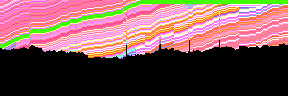

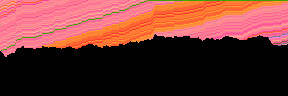

Top 2 values: tensor([0.8794, 0.8670])
Top 2 Neighbor Labels: [0, 4]
Final kNN Prediction for Real Sample: 0
Real Sample label: 4
Most common sim label: 4


In [ ]:
import torch
import torch.nn.functional as F
from collections import Counter
from transformers import AutoImageProcessor, AutoModel

# Loading ViT-S+ model
model_name = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

# Build the 'Gallery' of Simulated Data
gallery_embeddings = []
gallery_labels = []

# Loop through a few samples to build reference database
for i, sim_sample in enumerate(dataset):
    if i > 1: # 50 reference points
      break

    # Get the simulated image and its label
    # (Assuming sim.images.npy.gz holds multiple types, we take the primary one)
    sim_data = sim_sample["sim.images.npy.gz"][sim_sample["label.cls"], 0]
    label = sim_sample["label.cls"]

    # Extract DINO embedding
    inputs = prep_genomic_image(sim_data)
    with torch.no_grad():
        emb = model(**inputs).pooler_output
        emb = F.normalize(emb, p=2, dim=1)

    gallery_embeddings.append(emb)
    gallery_labels.append(label)

    display(Image.fromarray(sim_data[:, :, [0, 1, 5]]))

most_common_sim_label = Counter(gallery_labels).most_common(1)[0][0]

# Stack embeddings into a single matrix [50, 384]
gallery_tensor = torch.cat(gallery_embeddings)

# Predict for a 'Real' Sample
k = 2
real_data = sample["image.npy.gz"]
real_label = sample["label.cls"]
real_inputs = prep_genomic_image(real_data)

with torch.no_grad():
    real_emb = model(**real_inputs).pooler_output
    real_emb = F.normalize(real_emb, p=2, dim=1)

# The kNN Search (Matrix Multiplication)
# Calculates similarity between the 1 real image and ALL 50 gallery images
similarities = torch.mm(real_emb, gallery_tensor.T) # Result shape: [1, 50]

# Find the indices of the top K most similar images
top_k_values, top_k_indices = torch.topk(similarities, k)

# top_k_values = [top_k_values[0] for val in top_k_values]
predicted_labels = [gallery_labels[idx] for idx in top_k_indices[0]]
final_prediction = Counter(predicted_labels).most_common(1)[0][0]

print(f"Top {k} values: {top_k_values[0]}")
print(f"Top {k} Neighbor Labels: {predicted_labels}")
print(f"Final kNN Prediction for Real Sample: {final_prediction}")
print(f"Real Sample label: {real_label}")
print(f"Most common sim label: {most_common_sim_label}")


**Results**

*Real sample Label 4 (n=0)*

ViTS+ 50 reference (sim) and k = 10:
Top 10 Neighbor Labels: [1, 0, 1, 0, 4, 0, 0, 0, 1, 8], 0

ViTS+ 50 reference and k = 50:
Final kNN Prediction for Real Sample: 0

ViTS+ 100 reference and k = 50:
Final kNN Prediction for Real Sample: 0

ViTS+ 1000 reference and k = 50:
Final kNN Prediction for Real Sample: 0

ViTL 50 reference and k = 10:
Top 10 Neighbor Labels: [0, 1, 0, 0, 0, 0, 0, 0, 1, 0], 0

ViTL 100 reference and k = 50:
Final kNN Prediction for Real Sample: 0

*Real Sample Label 0 (n=1)*

ViTS+ 100 reference and k = 10:
[1, 1, 0, 0, 0, 1, 0, 0, 1, 1], 1

ViTL 100 reference k = 10:
[1, 0, 1, 0, 1, 1, 0, 0, 0, 8], 0

*Real Sample Label 1 (n=5)*

ViTS+ 100 reference k = 10:
[1, 5, 1, 3, 0, 0, 0, 0, 0, 3], 0

ViTL 100 reference k = 10:
[3, 0, 0, 3, 3, 1, 0, 1, 0, 0], 0

*Real Sample Label 3 (n=21)*

ViTS+ 100 reference k = 10:
[3, 3, 1, 1, 4, 0, 0, 0, 1, 0], 0

ViTL 100 reference k = 10:
[0, 1, 3, 3, 0, 3, 0, 0, 0, 0], 0

*Real Sample Label 8 (n=6)*

ViTS+ 100 reference k = 10:
[1, 1, 1, 0, 1, 3, 3, 3, 3, 2], 1

ViTL 100 reference k = 10:
[1, 0, 3, 1, 3, 0, 10, 3, 8, 3], 3

### Convolutional Layer for 7 channels -> 3 channel RGB

Condense 7 channels into 3 with convolutional layer at the beginning ofpipeline. Learns most effective way to combine the 7 input channels into 3 with DINOv3 model which expects 3 channel RGB input (Learned feature engineering where model determines optimal weights/combinations).

In [ ]:
import torch.nn as nn

class CustomInputLayer(nn.Module):
    def __init__(self):
        super().__init__()
        # Define a 1x1 convolution to reduce 7 channels to 3
        # This layer will learn the best combination of input channels
        self.conv = nn.Conv2d(in_channels=7, out_channels=3, kernel_size=1)

    def forward(self, x):
        # x is expected to be a PyTorch tensor with shape (B, C, H, W)
        # where C=7, H=96, W=288
        return self.conv(x)

# Instantiate the custom input layer
custom_input_converter = CustomInputLayer().to(model.device)

def prep_genomic_image_conv(data, processor, model_device):
    # Convert numpy array to PyTorch tensor and move to model device
    # Permute to (C, H, W) for Conv2d input
    img_tensor = torch.from_numpy(data).permute(2, 0, 1).float().unsqueeze(0).to(model_device)

    # Apply the custom convolutional layer to get 3 channels
    processed_3ch_tensor = custom_input_converter(img_tensor)

    # Convert back to PIL Image for DINO processor, resizing implicitly
    # Permute to (H, W, C) for Image.fromarray
    # Scale to 0-255 if the output of conv is not already in that range
    # For simplicity here, we'll assume the output is suitable or normalize if needed.
    # A more robust solution might involve activation and normalization in CustomInputLayer.
    processed_3ch_array = (processed_3ch_tensor.squeeze(0).permute(1, 2, 0).detach().cpu().numpy())

    # Normalize to 0-255 range if values are not already there
    processed_3ch_array = (processed_3ch_array - processed_3ch_array.min()) / (processed_3ch_array.max() - processed_3ch_array.min()) * 255
    processed_3ch_array = processed_3ch_array.astype('uint8')

    img = Image.fromarray(processed_3ch_array).convert("RGB").resize((224, 224))
    return processor(images=img, return_tensors="pt").to(model_device)

### k-NN Classifier with 7->3 Convolution

In [ ]:
import torch
import torch.nn.functional as F
from collections import Counter
from transformers import AutoImageProcessor, AutoModel

# Loading ViT-S+ model
model_name = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

# Build the 'Gallery' of Simulated Data
gallery_embeddings = []
gallery_labels = []

# Loop through a few samples to build reference database
for i, sim_sample in enumerate(dataset):
    if i > 50: # 50 reference points
      break

    # Get the simulated image and its label
    # (Assuming sim.images.npy.gz holds multiple types, we take the primary one)
    sim_data = sim_sample["sim.images.npy.gz"][sim_sample["label.cls"], 0]
    sim_label = sim_sample["label.cls"]
    sim_inputs = prep_genomic_image_conv(sim_data, processor, model.device)

    with torch.no_grad():
      sim_emb = model(**sim_inputs).pooler_output
      sim_emb = F.normalize(sim_emb, p=2, dim=1)

    gallery_embeddings.append(sim_emb)
    gallery_labels.append(sim_label)

    # display(Image.fromarray(sim_data[:, :, [0, 1, 5]]))

most_common_sim_label = Counter(gallery_labels).most_common(1)[0][0]

# Stack embeddings into a single matrix [50, 384]
gallery_tensor = torch.cat(gallery_embeddings)

# Predict for a 'Real' Sample
k = 10
k = k if k <= i else i
real_data = sample["image.npy.gz"]
real_label = sample["label.cls"]
real_inputs = prep_genomic_image_conv(real_data, processor, model.device)

with torch.no_grad():
    real_emb = model(**real_inputs).pooler_output
    real_emb = F.normalize(real_emb, p=2, dim=1)

# display(Image.fromarray(real_data[:, :, [0, 1, 5]]))

# The kNN Search (Matrix Multiplication)
# Calculates similarity between the 1 real image and ALL 50 gallery images
similarities = torch.mm(real_emb, gallery_tensor.T) # Result shape: [1, 50]

# Find the indices of the top K most similar images
top_k_values, top_k_indices = torch.topk(similarities, k)

predicted_labels = [gallery_labels[idx] for idx in top_k_indices[0]]
final_prediction = Counter(predicted_labels).most_common(1)[0][0]

print(f"Top {k} values: {top_k_values[0]}")
print(f"Top {k} Neighbor Labels: {predicted_labels}")
print(f"Final kNN Prediction for Real Sample: {final_prediction}")
print(f"Real Sample label: {real_label}")
print(f"Most common sim label: {most_common_sim_label}")

Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

Top 10 values: tensor([0.9467, 0.9420, 0.9370, 0.9302, 0.9286, 0.9268, 0.9257, 0.9199, 0.9155,
        0.9133])
Top 10 Neighbor Labels: [1, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Final kNN Prediction for Real Sample: 0
Real Sample label: 4
Most common sim label: 0


## Results
**Real Sample Label 0 (n=1)**

ViTS+ 50 reference k = 10: [0, 0, 0, 0, 1, 0, 0, 1, 1, 0], 0

ViTL 50 reference k = 10: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0], 0

**Real Sample Label 1 (n=5)**

ViTS+ 50 reference k = 10: [0, 0, 1, 0, 1, 0, 5, 3, 0, 0], 0

ViTL 50 reference k = 10: [1, 0, 0, 0, 0, 3, 0, 0, 1, 8], 0

**Real Sample Label 3 (n=21)**

ViTS+ 50 reference k = 10: [1, 0, 0, 0, 4, 0, 0, 5, 0, 0], 0

ViTL 50 reference k = 10: [1, 4, 0, 0, 0, 0, 0, 0, 0, 0], 0

**Real Sample Label 4 (n=0)**

ViTS+ 50 reference k = 10: [1, 0, 1, 0, 0, 0, 0, 0, 0, 0], 0

ViTL 50 reference k = 10: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0], 0

ViTS+ 100 reference k = 10: [1, 0, 0, 0, 1, 0, 0, 3, 0, 1], 0

ViTL 100 reference k = 10: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 0

**Real Sample Label 8 (n=6)**

ViTS+ 50 reference k = 10: [0, 3, 1, 0, 3, 1, 8, 0, 0, 0], 0

ViTL 50 reference k = 10: [1, 0, 1, 1, 8, 3, 0, 4, 3, 1], 1